# Error Budget: PCA Dimensions and Coefficient Accuracy $\to$ Waveform Mismatch

**PCA in physical d$\Phi$ space** (not log space) — PCA minimizes absolute error in the dephasing,
which directly controls the waveform phase error and hence the mismatch.

Decompose the surrogate-model error into two independent sources:
1. **PCA truncation**: mismatch when using K basis functions with *perfect* coefficient recovery
2. **Coefficient noise**: additional mismatch from imperfect MLP coefficient predictions

This determines **(a)** how many PCA components are needed and **(b)** how accurate the MLP must be.

In [1]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d

np.random.seed(0)

# ---------- Constants ----------
G    = 6.67430e-11
C    = 2.99792458e8
MSUN = 1.98892e30
YR   = 365.25 * 86400.0
TAU_YR = 4.0

# ---------- Load data ----------
DATA_DIR = "data"
files = sorted(glob.glob(os.path.join(DATA_DIR, "dephasing_sample_*.csv")),
               key=lambda p: int(re.search(r"_(\d+)\.csv$", p).group(1)))

def parse_file(path):
    with open(path) as fh:
        lines = fh.readlines()
    params = {}
    for item in lines[0].strip().split(","):
        k, v = item.split("=")
        params[k.strip()] = float(v)
    data = np.loadtxt(lines[2:], delimiter=",")
    return params, data[:, 0], data[:, 1]

m1  = np.empty(len(files))
m2  = np.empty(len(files))
rho = np.empty(len(files))
gsp = np.empty(len(files))
fs, dphis = [], []
for i, fp in enumerate(files):
    p, f, d = parse_file(fp)
    m1[i], m2[i], rho[i], gsp[i] = p["m1"], p["m2"], p["rhosp"], p["gsp"]
    fs.append(f); dphis.append(d)

# ---------- Frequency normalization ----------
def f_isco(m1_msun, m2_msun):
    M = (m1_msun + m2_msun) * MSUN
    return C**3 / (6**1.5 * np.pi * G * M)

def f_tau(m1_msun, m2_msun, tau_sec=TAU_YR * YR):
    Mc = (m1_msun * m2_msun)**(3/5) / (m1_msun + m2_msun)**(1/5) * MSUN
    return (1.0 / np.pi) * (5.0 / (256.0 * tau_sec))**(3/8) * (G * Mc / C**3)**(-5/8)

fc        = f_isco(m1, m2)
f_tau_arr = f_tau(m1, m2)

# Drop last point (dPh=0 at merger) and keep physical dPhi (no log transform)
xs, phys_dphis = [], []
for i in range(len(files)):
    x = (fs[i][:-1] - fc[i]) / (f_tau_arr[i] - fc[i])
    xs.append(x)
    phys_dphis.append(dphis[i][:-1])

xmins = np.array([x.min() for x in xs])
xmaxs = np.array([x.max() for x in xs])
X_LO  = float(np.max(xmins))
X_HI  = float(np.min(xmaxs))
N_X   = 200
x_grid = np.linspace(X_LO, X_HI, N_X)

# Y matrix: physical dPhi on common x-grid (NOT log-transformed)
Y = np.empty((len(files), N_X))
for i in range(len(files)):
    xi = xs[i][::-1]
    yi = phys_dphis[i][::-1]
    Y[i] = np.interp(x_grid, xi, yi)

# ---------- Train / test split (same seed as training notebook) ----------
idx = np.arange(len(files))
idx_trainval, idx_test = train_test_split(idx, test_size=0.10, random_state=0)
idx_train, idx_val     = train_test_split(idx_trainval, test_size=1/9, random_state=0)
n_test = len(idx_test)

print(f"Loaded {len(files)} systems, test set: {n_test}")
print(f"Common x-grid: [{X_LO:.4f}, {X_HI:.4f}], {N_X} points")
print(f"Y (dPhi) range: [{Y.min():.2e}, {Y.max():.2e}] rad")

Loaded 10000 systems, test set: 1000
Common x-grid: [0.0237, 1.0001], 200 points
Y (dPhi) range: [2.06e-08, 1.93e+06] rad


In [2]:
# LISA noise and waveform functions (from Eval notebook)
L      = 2.5e9
f_star = C / (2 * np.pi * L)
M_sun  = 1.98847e30

def P_OMS(f):
    return (1.5e-11)**2 * (1 + (2e-3 / f)**4)

def P_acc(f):
    return (3e-15)**2 * (1 + (0.4e-3 / f)**2) * (1 + (f / 8e-3)**4)

def S_n(f):
    return ((10 / (3 * L**2)) *
            (P_OMS(f) + 2 * (1 + np.cos(f / f_star)**2) * P_acc(f) / (2 * np.pi * f)**4) *
            (1 + (6/10) * (f / f_star)**2))

def phi_vacuum(f, chirp_mass):
    a_V = (C**3) / (np.pi * G * chirp_mass * f)
    return (1/16) * a_V**(5/3)

def phi_ddot_vacuum(f, chirp_mass):
    a_V = (np.pi * G * chirp_mass / C**3)**(-5/3)
    return (12 * np.pi**2 * f**(11/3)) / (5 * a_V)

def h0(f, chirp_mass, phi_dd):
    prefactor = 0.5 * (4 * np.pi**(2/3) * G**(5/3) * chirp_mass**(5/3) * f**(2/3)) / C**4
    return prefactor * np.sqrt(2 * np.pi / phi_dd)

def build_waveform(f, delta_phi, m1_msun, m2_msun):
    m1_kg = m1_msun * M_sun
    m2_kg = m2_msun * M_sun
    chirp_mass = (m1_kg * m2_kg)**(3/5) / (m1_kg + m2_kg)**(1/5)
    phi_v  = phi_vacuum(f, chirp_mass)
    phi_dd = phi_ddot_vacuum(f, chirp_mass)
    return h0(f, chirp_mass, phi_dd) * np.exp(1j * (phi_v - delta_phi))

def inner_product(a, b, f):
    return 4 * np.real(np.trapezoid(np.conj(a) * b / S_n(f), f))

def overlap_maximized(h1, h2, f):
    df = f[1] - f[0]
    z  = 4 * np.fft.ifft(np.conj(h1) * h2 / S_n(f)) * len(f) * df
    return np.max(np.abs(z))

def resample_waveform_data(f, dphi, n_points=4000):
    f_uniform = np.linspace(f.min(), f.max(), n_points)
    return f_uniform, interp1d(f, dphi, kind="cubic")(f_uniform)

SNR_BENCHMARK = 200
N_PARAMS = 4
M_c = N_PARAMS / (2 * SNR_BENCHMARK**2)
print(f"Critical mismatch M_c = {M_c:.2e}")

Critical mismatch M_c = 5.00e-05


In [3]:
# Y is now physical dPhi — no exp() needed
print("Precomputing truth waveforms for test set...")
precomp = []
for j in range(n_test):
    sys_i = idx_test[j]
    f_axis = x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i]
    dphi_true = Y[sys_i]
    f_dense, dphi_true_dense = resample_waveform_data(f_axis, dphi_true)
    h_true = build_waveform(f_dense, dphi_true_dense, m1[sys_i], m2[sys_i])
    dd = np.real(inner_product(h_true, h_true, f_dense))
    precomp.append({
        'f_axis': f_axis,
        'f_dense': f_dense,
        'h_true': h_true,
        'dd': dd,
        'm1': m1[sys_i],
        'm2': m2[sys_i],
    })
print("Done.")

def fast_mismatch(Y_recon_j, j):
    p = precomp[j]
    dphi_pred = Y_recon_j
    dphi_pred_dense = interp1d(p['f_axis'], dphi_pred, kind='cubic')(p['f_dense'])
    h_pred = build_waveform(p['f_dense'], dphi_pred_dense, p['m1'], p['m2'])
    hd = overlap_maximized(h_pred, p['h_true'], p['f_dense'])
    hh = np.real(inner_product(h_pred, h_pred, p['f_dense']))
    F = np.clip(hd / np.sqrt(hh * p['dd']), 0.0, 1.0)
    return 1 - F

Precomputing truth waveforms for test set...
Done.


# Part 1: PCA Reconstruction Mismatch vs Number of Components (K)

With *perfect* coefficient recovery, how many PCA components are needed for the
reconstructed dephasing to produce faithful waveforms (mismatch $< M_c$)?

In [4]:
MAX_K = 100
pca_full = PCA(n_components=MAX_K).fit(Y[idx_train])
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
print("Cumulative explained variance:")
for k in range(MAX_K):
    print(f"  K={k+1:2d}  {cumvar[k]:.10f}")

# Project test curves onto full basis
coeffs_test_full = pca_full.transform(Y[idx_test])

# Compute mismatch for each K
mismatch_vs_K = np.full((MAX_K, n_test), np.nan)

for K in range(1, MAX_K + 1):
    Y_recon = coeffs_test_full[:, :K] @ pca_full.components_[:K] + pca_full.mean_
    for j in range(n_test):
        mismatch_vs_K[K-1, j] = fast_mismatch(Y_recon[j], j)

    med = np.median(mismatch_vs_K[K-1])
    frac = np.mean(mismatch_vs_K[K-1] > M_c)
    p95 = np.percentile(mismatch_vs_K[K-1], 95)
    print(f"K={K:2d}  median M={med:.3e}  p95={p95:.3e}  frac>Mc={frac:.3f}")

Cumulative explained variance:
  K= 1  0.9412800752
  K= 2  0.9925755695
  K= 3  0.9990168810
  K= 4  0.9998872510
  K= 5  0.9999886855
  K= 6  0.9999990578
  K= 7  0.9999999190
  K= 8  0.9999999916
  K= 9  0.9999999977
  K=10  0.9999999985
  K=11  0.9999999990
  K=12  0.9999999993
  K=13  0.9999999995
  K=14  0.9999999996
  K=15  0.9999999997
  K=16  0.9999999998
  K=17  0.9999999998
  K=18  0.9999999999
  K=19  0.9999999999
  K=20  0.9999999999
  K=21  0.9999999999
  K=22  1.0000000000
  K=23  1.0000000000
  K=24  1.0000000000
  K=25  1.0000000000
  K=26  1.0000000000
  K=27  1.0000000000
  K=28  1.0000000000
  K=29  1.0000000000
  K=30  1.0000000000
  K=31  1.0000000000
  K=32  1.0000000000
  K=33  1.0000000000
  K=34  1.0000000000
  K=35  1.0000000000
  K=36  1.0000000000
  K=37  1.0000000000
  K=38  1.0000000000
  K=39  1.0000000000
  K=40  1.0000000000
  K=41  1.0000000000
  K=42  1.0000000000
  K=43  1.0000000000
  K=44  1.0000000000
  K=45  1.0000000000
  K=46  1.0000000000
  K

In [5]:
# Log-space PCA K sweep for comparison
# Build log(dPhi) Y matrix and run the same sweep
print("Running log-space PCA K sweep for comparison...")
Y_log = np.log(Y)

pca_log_full = PCA(n_components=MAX_K).fit(Y_log[idx_train])
coeffs_test_log = pca_log_full.transform(Y_log[idx_test])

mismatch_vs_K_log = np.full((MAX_K, n_test), np.nan)
for K in range(1, MAX_K + 1):
    Y_recon_log = coeffs_test_log[:, :K] @ pca_log_full.components_[:K] + pca_log_full.mean_
    Y_recon_phys = np.exp(Y_recon_log)
    for j in range(n_test):
        mismatch_vs_K_log[K-1, j] = fast_mismatch(Y_recon_phys[j], j)

    frac = np.mean(mismatch_vs_K_log[K-1] > M_c)
    if K <= 20 or K % 10 == 0:
        print(f"  K={K:3d}  frac>Mc={frac:.3f}")

print("Done.")

Running log-space PCA K sweep for comparison...
  K=  1  frac>Mc=0.994
  K=  2  frac>Mc=0.995
  K=  3  frac>Mc=0.972
  K=  4  frac>Mc=0.969
  K=  5  frac>Mc=0.933
  K=  6  frac>Mc=0.861
  K=  7  frac>Mc=0.803
  K=  8  frac>Mc=0.656
  K=  9  frac>Mc=0.601
  K= 10  frac>Mc=0.515
  K= 11  frac>Mc=0.506
  K= 12  frac>Mc=0.503
  K= 13  frac>Mc=0.487
  K= 14  frac>Mc=0.467
  K= 15  frac>Mc=0.455
  K= 16  frac>Mc=0.450
  K= 17  frac>Mc=0.448
  K= 18  frac>Mc=0.447
  K= 19  frac>Mc=0.450
  K= 20  frac>Mc=0.447
  K= 30  frac>Mc=0.435
  K= 40  frac>Mc=0.437
  K= 50  frac>Mc=0.428
  K= 60  frac>Mc=0.413
  K= 70  frac>Mc=0.409
  K= 80  frac>Mc=0.405
  K= 90  frac>Mc=0.394
  K=100  frac>Mc=0.383
Done.


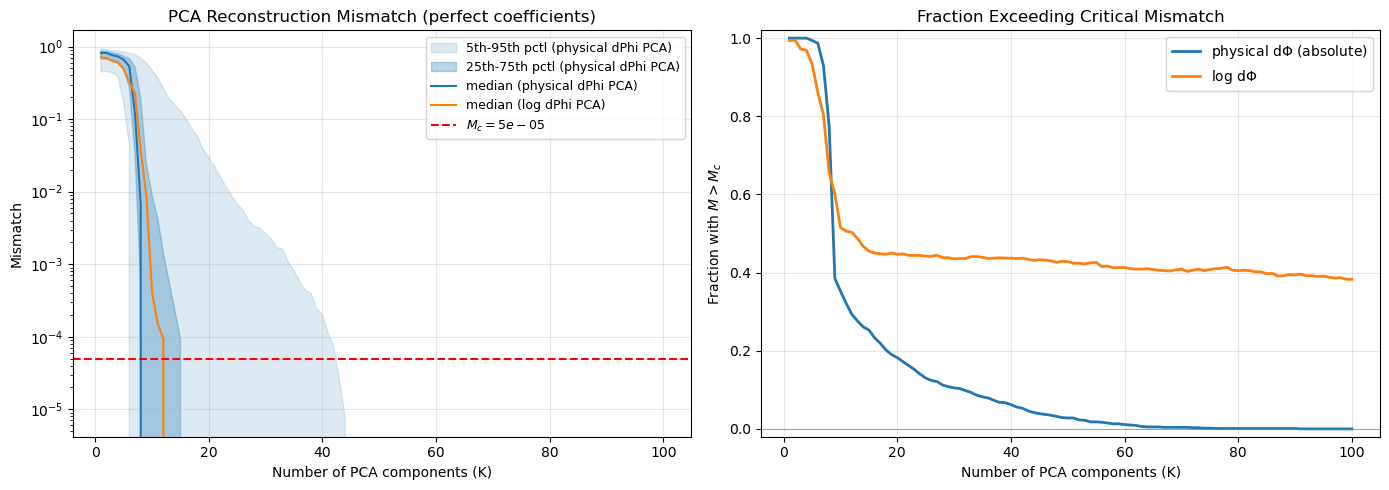

Minimum K for 100% of systems below M_c: K=91


In [6]:
Ks = np.arange(1, MAX_K + 1)
medians = np.array([np.median(mismatch_vs_K[k]) for k in range(MAX_K)])
medians_log = np.array([np.median(mismatch_vs_K_log[k]) for k in range(MAX_K)])
p5  = np.array([np.percentile(mismatch_vs_K[k], 5) for k in range(MAX_K)])
p25 = np.array([np.percentile(mismatch_vs_K[k], 25) for k in range(MAX_K)])
p75 = np.array([np.percentile(mismatch_vs_K[k], 75) for k in range(MAX_K)])
p95 = np.array([np.percentile(mismatch_vs_K[k], 95) for k in range(MAX_K)])
fracs = np.array([np.mean(mismatch_vs_K[k] > M_c) for k in range(MAX_K)])
fracs_log = np.array([np.mean(mismatch_vs_K_log[k] > M_c) for k in range(MAX_K)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.fill_between(Ks, p5, p95, alpha=0.15, color='C0', label='5th-95th pctl (physical dPhi PCA)')
ax1.fill_between(Ks, p25, p75, alpha=0.3, color='C0', label='25th-75th pctl (physical dPhi PCA)')
ax1.plot(Ks, medians, '-', color='C0', lw=1.5, label='median (physical dPhi PCA)')
ax1.plot(Ks, medians_log, '-', color='C1', lw=1.5, label='median (log dPhi PCA)')
ax1.axhline(M_c, color='red', ls='--', lw=1.5, label=f'$M_c = {M_c:.0e}$')
ax1.set(xlabel='Number of PCA components (K)', ylabel='Mismatch',
        yscale='log', title='PCA Reconstruction Mismatch (perfect coefficients)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(Ks, fracs, '-', color='C0', lw=2, label='physical d$\\Phi$ (absolute)')
ax2.plot(Ks, fracs_log, '-', color='C1', lw=2, label='log d$\\Phi$')
ax2.axhline(0, color='grey', ls='-', lw=0.5)
ax2.set(xlabel='Number of PCA components (K)', ylabel=r'Fraction with $M > M_c$',
        title='Fraction Exceeding Critical Mismatch', ylim=(-0.02, 1.02))
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Report the minimum K where all or nearly all systems pass
K_opt = None
for k in range(MAX_K):
    if fracs[k] == 0:
        K_opt = k + 1
        print(f"Minimum K for 100% of systems below M_c: K={K_opt}")
        break
if K_opt is None:
    for thresh in [0.01, 0.05, 0.10]:
        for k in range(MAX_K):
            if fracs[k] <= thresh:
                print(f"First K with <= {thresh*100:.0f}% exceeding M_c: K={k+1} ({fracs[k]*100:.1f}%)")
                if K_opt is None:
                    K_opt = k + 1
                break
    if K_opt is None:
        K_opt = MAX_K
        print(f"Warning: even K={MAX_K} has {fracs[-1]*100:.1f}% exceeding M_c")

# Part 2: Coefficient Noise Sensitivity

For a given K, how much noise in the PCA coefficients can be tolerated?

**Noise model**: add i.i.d. Gaussian noise to the *normalized* PCA coefficients
(zero mean, unit variance on training set). The noise std $\sigma_n$ in normalized
space directly corresponds to the MLP's per-component prediction RMSE.

In [13]:
# K values for the noise analysis: always K=4 (current), plus the optimal K from Part 1
K_VALUES = sorted(set([4, 20, 40, 60, 80, 100]))
print(f"Noise analysis at K = {K_VALUES}")

# Noise levels to sweep (log-spaced)
sigma_ns = np.logspace(-8, -1, 16)

noise_results = {}

for K in K_VALUES:
    print(f"\n{'='*60}")
    print(f"K = {K}")
    print(f"{'='*60}")

    pca_K = PCA(n_components=K).fit(Y[idx_train])
    c_test = pca_K.transform(Y[idx_test])
    c_train = pca_K.transform(Y[idx_train])
    c_std_K = c_train.std(axis=0)

    mismatch_noise = np.full((len(sigma_ns), n_test), np.nan)

    for si, sigma_n in enumerate(sigma_ns):
        noise = np.random.randn(n_test, K) * sigma_n
        c_noisy = c_test + noise * c_std_K
        Y_recon = pca_K.inverse_transform(c_noisy)

        for j in range(n_test):
            mismatch_noise[si, j] = fast_mismatch(Y_recon[j], j)

        med = np.median(mismatch_noise[si])
        frac = np.mean(mismatch_noise[si] > M_c)
        print(f"  sigma_n={sigma_n:.3e}  median M={med:.3e}  frac>Mc={frac:.3f}")

    noise_results[K] = mismatch_noise

Noise analysis at K = [4, 20, 40, 60, 80, 100]

K = 4
  sigma_n=1.000e-08  median M=7.310e-01  frac>Mc=1.000
  sigma_n=2.929e-08  median M=7.310e-01  frac>Mc=1.000
  sigma_n=8.577e-08  median M=7.310e-01  frac>Mc=1.000
  sigma_n=2.512e-07  median M=7.311e-01  frac>Mc=1.000
  sigma_n=7.356e-07  median M=7.311e-01  frac>Mc=1.000
  sigma_n=2.154e-06  median M=7.308e-01  frac>Mc=1.000
  sigma_n=6.310e-06  median M=7.304e-01  frac>Mc=1.000
  sigma_n=1.848e-05  median M=7.300e-01  frac>Mc=1.000
  sigma_n=5.412e-05  median M=7.278e-01  frac>Mc=1.000
  sigma_n=1.585e-04  median M=7.265e-01  frac>Mc=1.000
  sigma_n=4.642e-04  median M=7.284e-01  frac>Mc=1.000
  sigma_n=1.359e-03  median M=7.228e-01  frac>Mc=1.000
  sigma_n=3.981e-03  median M=7.247e-01  frac>Mc=1.000
  sigma_n=1.166e-02  median M=7.434e-01  frac>Mc=1.000
  sigma_n=3.415e-02  median M=7.710e-01  frac>Mc=1.000
  sigma_n=1.000e-01  median M=7.941e-01  frac>Mc=1.000

K = 20
  sigma_n=1.000e-08  median M=0.000e+00  frac>Mc=0.182
  s

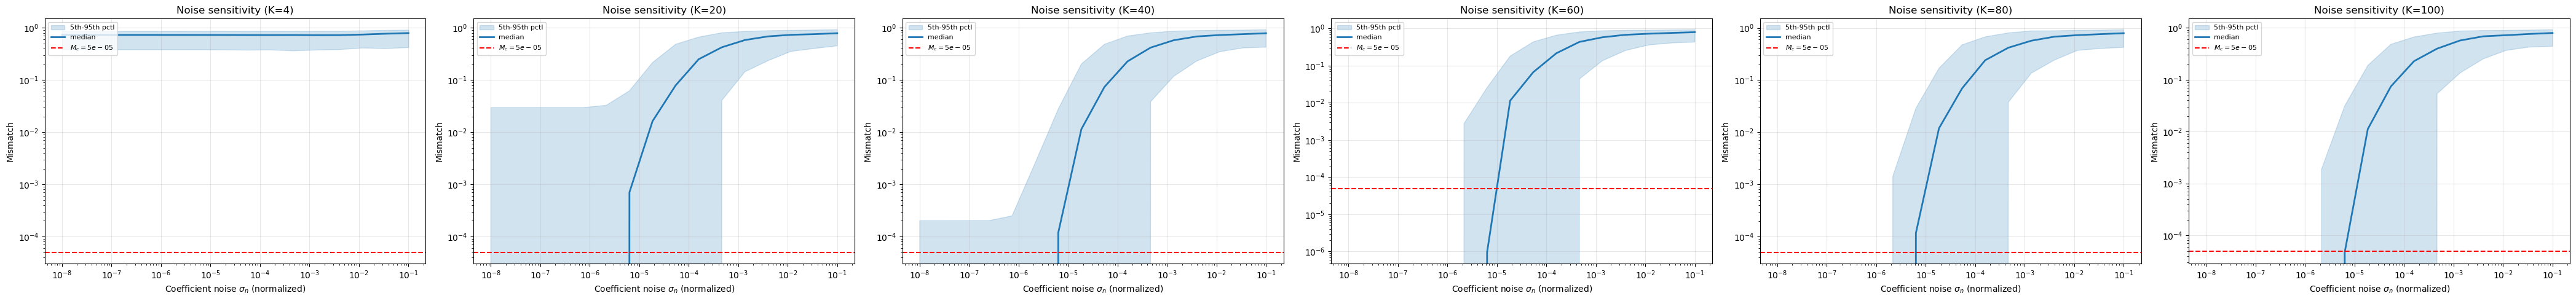

In [14]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(7*len(K_VALUES), 5), squeeze=False)

for col, K in enumerate(K_VALUES):
    ax = axes[0, col]
    mm = noise_results[K]

    med  = np.array([np.median(mm[si]) for si in range(len(sigma_ns))])
    p5   = np.array([np.percentile(mm[si], 5) for si in range(len(sigma_ns))])
    p95  = np.array([np.percentile(mm[si], 95) for si in range(len(sigma_ns))])

    ax.fill_between(sigma_ns, p5, p95, alpha=0.2, color='C0', label='5th-95th pctl')
    ax.plot(sigma_ns, med, '-', color='C0', lw=2, label='median')
    ax.axhline(M_c, color='red', ls='--', lw=1.5, label=f'$M_c = {M_c:.0e}$')
    ax.set(xlabel=r'Coefficient noise $\sigma_n$ (normalized)', ylabel='Mismatch',
           xscale='log', yscale='log', title=f'Noise sensitivity (K={K})')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

K=4: even sigma_n=1.000e-08 has 100.0% exceeding M_c
K=20: even sigma_n=1.000e-08 has 18.2% exceeding M_c
K=40: even sigma_n=1.000e-08 has 6.2% exceeding M_c
K=60: even sigma_n=1.000e-08 has 1.1% exceeding M_c
K=80: max sigma_n for <=1% exceeding M_c: 7.356e-07
K=100: max sigma_n for <=1% exceeding M_c: 7.356e-07


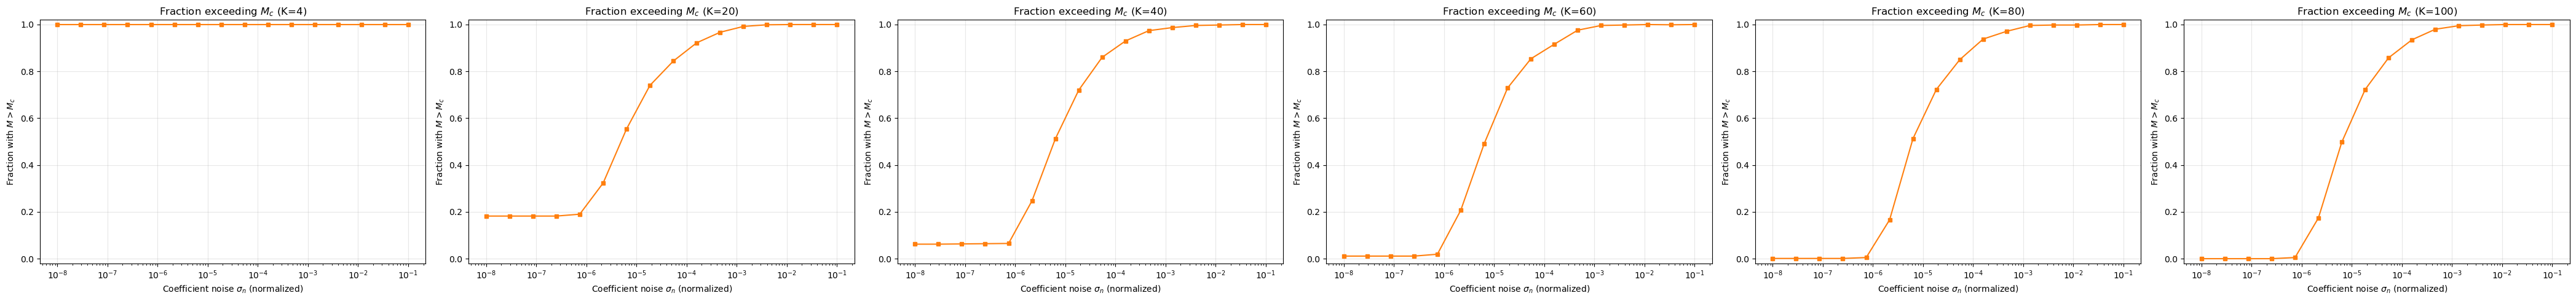

In [15]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(7*len(K_VALUES), 5), squeeze=False)

for col, K in enumerate(K_VALUES):
    ax = axes[0, col]
    mm = noise_results[K]

    fracs_noise = np.array([np.mean(mm[si] > M_c) for si in range(len(sigma_ns))])

    ax.plot(sigma_ns, fracs_noise, 's-', color='C1', ms=4)
    ax.set(xlabel=r'Coefficient noise $\sigma_n$ (normalized)',
           ylabel=r'Fraction with $M > M_c$',
           xscale='log', title=f'Fraction exceeding $M_c$ (K={K})',
           ylim=(-0.02, 1.02))
    ax.grid(alpha=0.3)

    # Find critical sigma_n
    for si in range(len(sigma_ns)-1, -1, -1):
        if fracs_noise[si] <= 0.01:
            print(f"K={K}: max sigma_n for <=1% exceeding M_c: {sigma_ns[si]:.3e}")
            break
    else:
        print(f"K={K}: even sigma_n={sigma_ns[0]:.3e} has {fracs_noise[0]*100:.1f}% exceeding M_c")

plt.tight_layout()
plt.show()

# Summary: Requirements for Faithful Waveform Surrogates

In [16]:
print("=" * 70)
print("ERROR BUDGET SUMMARY")
print("=" * 70)

# PCA truncation
print("\n1. PCA TRUNCATION (perfect coefficient recovery)")
print("-" * 50)
for k in range(MAX_K):
    frac_k = np.mean(mismatch_vs_K[k] > M_c)
    status = "PASS" if frac_k == 0 else f"{frac_k*100:.1f}% exceed M_c"
    print(f"   K={k+1:3d}  median M={np.median(mismatch_vs_K[k]):.2e}  {status}")
    if frac_k == 0 and k > 0 and np.mean(mismatch_vs_K[k-1] > M_c) > 0:
        print(f"   >>> Minimum K for universal faithfulness: {k+1}")

# Noise tolerance
print("\n2. COEFFICIENT NOISE TOLERANCE")
print("-" * 50)
for K in K_VALUES:
    mm = noise_results[K]
    fracs_noise = np.array([np.mean(mm[si] > M_c) for si in range(len(sigma_ns))])
    sigma_crit = None
    for si in range(len(sigma_ns)-1, -1, -1):
        if fracs_noise[si] <= 0.01:
            sigma_crit = sigma_ns[si]
            break
    if sigma_crit is not None:
        print(f"   K={K}: max sigma_n for <=1% exceeding M_c: {sigma_crit:.3e}")
        print(f"          (MLP must achieve per-component RMSE < {sigma_crit:.3e})")
    else:
        print(f"   K={K}: PCA floor already too high; noise tolerance near zero")
print("=" * 70)

ERROR BUDGET SUMMARY

1. PCA TRUNCATION (perfect coefficient recovery)
--------------------------------------------------
   K=  1  median M=8.19e-01  100.0% exceed M_c
   K=  2  median M=8.17e-01  100.0% exceed M_c
   K=  3  median M=7.62e-01  100.0% exceed M_c
   K=  4  median M=7.31e-01  100.0% exceed M_c
   K=  5  median M=6.61e-01  99.4% exceed M_c
   K=  6  median M=5.34e-01  98.7% exceed M_c
   K=  7  median M=1.20e-01  92.9% exceed M_c
   K=  8  median M=6.69e-03  77.3% exceed M_c
   K=  9  median M=0.00e+00  38.5% exceed M_c
   K= 10  median M=0.00e+00  35.2% exceed M_c
   K= 11  median M=0.00e+00  32.1% exceed M_c
   K= 12  median M=0.00e+00  29.3% exceed M_c
   K= 13  median M=0.00e+00  27.6% exceed M_c
   K= 14  median M=0.00e+00  26.1% exceed M_c
   K= 15  median M=0.00e+00  25.3% exceed M_c
   K= 16  median M=0.00e+00  23.3% exceed M_c
   K= 17  median M=0.00e+00  21.9% exceed M_c
   K= 18  median M=0.00e+00  20.2% exceed M_c
   K= 19  median M=0.00e+00  19.0% exceed M_c
